In [ ]:
import os
# manually specify the GPUs to use
os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"]="0"
import sys
import torch
import tqdm 
import pickle as pkl
import numpy as np


module_path = os.path.abspath('..')
if module_path not in sys.path:
    sys.path.insert(0, module_path)

from torch.utils.data import DataLoader
from datasets import TransformerConf4Dataset, CNFDataset
from models import TransformerConf3, LightningModelCNF
from utils import args_transformer, args_cnf, create_mask_src, create_mask_tgt

from config import FitConfig
from model_loader import GlobalModelLoader
from run_fit import VertexFitter



device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

torch.multiprocessing.set_sharing_strategy('file_system')

cfg = FitConfig(
    data_term="KL_combined",
    lam_a = 1e-5,
    adam_lr = 5e-2,
    adam_steps = 200,
    background_mode="none",

    n_sample_for_template=100,
    n_fit_per_event=100,
    use_lbfgs=False,
    lbfgs_steps=50,
)


In [2]:
# set up the models
model_loader = GlobalModelLoader(device)
model_loader.load_models()
model_loader.generator_args.particle_type = "proton_contained"





- Arguments:
  dataset_path: /pscratch/sd/b/botaoli/SFGD_VA/Data/NN_Data_compressed/{}/{}/{}/{}.zip
  metadata_path: /pscratch/sd/b/botaoli/SFGD_VA/Data/NN_Data_compressed/metadata.pkl
  event_in_folder: 100000
  seed: 42
  max_p: 5
  max_p_contained: 5
  max_p_exiting: 1
  mom_smearing_p: 0.07
  mom_smearing_mu: 0.07
  cube_size: 10.27
  va_size: 7
  pad_value: -10000
  hidden: 192
  dropout: 0.1
  encoder_layers: 10
  decoder_layers: 10
  attn_heads: 16
  batch_size: 16
  epochs: 12420
  num_workers: 32
  lr: 0.002
  accum_grad_batches: 4
  cosine_annealing_steps: 400
  weight_decay: 0.01
  beta1: 0.9
  beta2: 0.999
  eps: 1e-09
  warmup_steps: 20
  save_dir: logs
  name: v1
  log_every_n_steps: 50
  early_stop_patience: 0
  save_top_k: 1
  checkpoint_path: /pscratch/sd/b/botaoli/SFGD_VA/Results/checkpoints
  checkpoint_name: v3
  load_checkpoint: None
  gpus: [0]
  num_nodes: 1


/global/homes/b/botaoli/.conda/envs/env_nn/lib/python3.11/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


Model weights loaded!


In [3]:
from datasets import CNFDataset
# for test
args = model_loader.generator_model["proton_contained"].args
test_set = CNFDataset(args, split="val")
test_loader = DataLoader(test_set, collate_fn=test_set.collate_fn, batch_size=32,
                            num_workers=args.num_workers, shuffle=False)


In [4]:
print("proton_contained_ekin_mean: ", model_loader.generator_model["proton_contained"].metadata['statistics']['per_tree']['proton_contained']['true_iniekin']['mean'])
print("proton_contained_ekin_std: ", model_loader.generator_model["proton_contained"].metadata['statistics']['per_tree']['proton_contained']['true_iniekin']['std'])

proton_contained_ekin_mean:  38.85369349908855
proton_contained_ekin_std:  22.17926268532521


In [5]:
print("true_ekin: ", test_data["ekin_true"][0])
print("true_dir: ", test_data["dir_true"][0])
print("true_vtx: ", test_data["vtx_true"][0])
print("pred_ekin: ", test_data["ekin_pred"][0])
print("pred_dir: ", test_data["dir_pred"][0])
print("pred_vtx: ", test_data["vtx_pred"][0])
print("N_pred: ", test_data["N_pred"][0])
print("N_true: ", test_data["N_true"][0])



NameError: name 'test_data' is not defined

In [9]:
batch = next(iter(test_loader))
img_batch, parameters_batch, _ = batch
#convert to a tensor
fitter = VertexFitter(model_loader, cfg)
#result = fitter.fit(data, 0)


In [5]:
print(img_batch.shape)
print(parameters_batch.shape)


torch.Size([32, 125])
torch.Size([32, 7])


In [5]:
dataset = {}
# covert a batch to a list of ndarraies
dataset['hits'] = img_batch.numpy()[:]
dataset['parameters'] = parameters_batch.numpy()[:]

In [6]:
check = {k: v[:10] for k, v in dataset.items()}
smear = torch.rand(10, 1, device=device) * 2 - 1
ekin = torch.tensor(check['parameters'][:, 3], device=device).unsqueeze(1)
print(ekin * (1 + smear))
print(check['parameters'][:, 3])

NameError: name 'dataset' is not defined

In [10]:

result = fitter.fit(dataset, 1, "single_track", "proton_contained")

generated_voxels shape:  torch.Size([10000, 125])
TrackGenerator generated_voxels shape:  torch.Size([100, 125])
10.040727615356445 GB peak for this call
weights shape:  torch.Size([100])
x_recon shape:  torch.Size([100, 125])
calculating data loss:
data_term:  weighted_poisson
hit_mask:  tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]], device='cuda:0')
voxel_w:  tensor([[0.0500, 0.0500, 0.0500,  ..., 0.0500, 0.0500, 0.0500],
        [0.0500, 0.0500, 0.0500,  ..., 0.0500, 0.0500, 0.0500],
        [0.0500, 0.0500, 0.0500,  ..., 0.0500, 0.0500, 0.0500],
        ...,
        [0.0500, 0.0500, 0.0500,  ..., 0.0500, 0.0500, 0.0500],
        [0.0500, 0.0500, 0.0500,  ..., 0.0500, 0.0500, 0.0500],
        [0.0500, 0.0500, 0.0500,  ..., 0.0500, 0.0500, 0.0500]],
       device='cuda:0')
rate:  

In [14]:
print(result['ekin_pred'].shape)

torch.Size([100, 1])


In [16]:
pred_ekin = result['ekin_pred'].reshape(10, 10, 1)
pred_ekin = pred_ekin.detach().cpu().numpy()
print(pred_ekin.shape)
print(pred_ekin)
print(result['ekin_true'])

(10, 10, 1)
[[[7.4983185e+01]
  [3.9514103e+01]
  [2.3344944e+01]
  [3.5236359e-02]
  [7.3280037e+01]
  [2.5989235e+01]
  [7.7895386e+01]
  [6.5416763e+01]
  [1.1355968e+01]
  [1.6501236e-01]]

 [[7.5272842e+01]
  [4.2002014e+01]
  [2.3457310e+01]
  [6.4655304e-02]
  [7.3475212e+01]
  [2.4050600e+01]
  [7.8556923e+01]
  [6.5954941e+01]
  [1.4661623e+01]
  [1.8366623e-01]]

 [[7.5183594e+01]
  [4.3785938e+01]
  [2.2058151e+01]
  [5.8780289e-01]
  [7.3074600e+01]
  [2.3439156e+01]
  [7.7879250e+01]
  [6.6470253e+01]
  [1.6566719e+01]
  [1.5507507e-01]]

 [[7.5241020e+01]
  [4.2914364e+01]
  [2.3394848e+01]
  [4.6656418e-01]
  [7.3592712e+01]
  [2.4491463e+01]
  [7.8303574e+01]
  [6.6044456e+01]
  [1.5007925e+01]
  [3.3794403e-01]]

 [[7.5269112e+01]
  [3.9927364e+01]
  [2.1476017e+01]
  [2.4828720e-01]
  [7.0578812e+01]
  [2.3536264e+01]
  [7.7790810e+01]
  [6.6063026e+01]
  [1.6234760e+01]
  [4.5410538e-01]]

 [[7.5340530e+01]
  [4.2548447e+01]
  [2.2707745e+01]
  [1.0280495e+00]
  [7.2

In [13]:
pred_vtx = result['vtx_pred'].reshape(10, 10, 3)
pred_vtx = pred_vtx.mean(dim=0).detach().cpu().numpy()
print(pred_vtx.shape)
print(pred_vtx)
print(result['vtx_true'])


(10, 3)
[[ 2.582855   -2.6229177  -2.3286293 ]
 [ 2.179118    1.5992075   2.4744256 ]
 [ 4.7547064   2.71521    -0.47073862]
 [ 1.895455    0.5224353   1.0531901 ]
 [-0.3951978   3.1731966  -1.9227686 ]
 [ 2.5953174   3.2710545   2.4443953 ]
 [ 3.036897   -2.7768695   3.0766108 ]
 [ 1.2287996  -2.912835    2.3515651 ]
 [ 2.4195278   2.720416    5.4187255 ]
 [ 1.3130802   2.345844   -2.3379161 ]]
[array([ 1.7532384,  1.741765 , -0.4600345], dtype=float32), array([1.7348144 , 1.6838505 , 0.06731752], dtype=float32), array([ 1.6958131,  1.7632813, -2.4984186], dtype=float32), array([1.705771 , 1.6959268, 0.4205132], dtype=float32), array([1.7843993, 1.7178065, 2.265937 ], dtype=float32), array([1.7503297, 1.8133911, 0.8118859], dtype=float32), array([ 1.8172503,  1.7582281, -1.1014315], dtype=float32), array([1.7876077, 1.6987667, 2.8830519], dtype=float32), array([1.776016 , 1.7685521, 3.0849147], dtype=float32), array([ 1.6856178,  1.6958475, -1.4458206], dtype=float32)]


In [ ]:
import matplotlib.pyplot as plt
def check_fit_result(result, n_event, n_fit, data_set, cube_size):
    device = result['ekin_pred'].device
    dtype = result['ekin_pred'].dtype
    N_pred = data_set['N_pred']
    
    ekin_pred_raw = np.array([np.sum(chunk, axis=0) for chunk in data_set['ekin_pred']])
    #dir_pred_raw = np.array([chunk for chunk in data_set['dir_pred']])    
    vtx_pred_raw = torch.cat([torch.tensor(chunk, device=device, dtype=dtype).unsqueeze(0) for chunk in data_set['vtx_pred']], dim=0)
    vtx_pred_raw = vtx_pred_raw*cube_size*1.5
    
    #dir_pred_raw = dir_pred_raw
    vtx_pred_raw = vtx_pred_raw.cpu().numpy()

    pred_vtx = result['vtx_pred'].detach()
    pred_ekin = result['ekin_pred'].detach()
    #pred_dir = result['dir_pred'].detach()
    true_vtx = torch.tensor([result['vtx_true'][i] for i in range(n_event)]).detach()
    true_ekin = np.array([np.sum(chunk, axis=0) for chunk in result['ekin_true']])
    #true_dir = test_data['dir_true']
    
    accum_ind = np.array([np.sum(N_pred[:i]) for i in range(n_event+1)]).astype(int)
    
    pred_vtx = pred_vtx.reshape(n_event, n_fit, 3).mean(dim=1).cpu().numpy()
    pred_ekin = np.array([np.sum(pred_ekin[accum_ind[i]:accum_ind[i+1]].cpu().numpy(), axis=0) for i in range(n_event)])
    
    #pred_dir = pred_dir.reshape(n_event, n_fit, 3).mean(dim=1).cpu().numpy()
    true_vtx = true_vtx.reshape(n_event, 3).cpu().numpy()
    #true_ekin = true_ekin.reshape(n_event).cpu().numpy()    
    #true_dir = true_dir.reshape(n_event, 3).cpu().numpy()
    
    vtx_pred_raw_x = vtx_pred_raw[:, 0]
    vtx_pred_raw_y = vtx_pred_raw[:, 1]
    vtx_pred_raw_z = vtx_pred_raw[:, 2]
    pred_vtx_x = pred_vtx[:, 0]
    pred_vtx_y = pred_vtx[:, 1]
    pred_vtx_z = pred_vtx[:, 2]
    true_vtx_x = true_vtx[:, 0]
    true_vtx_y = true_vtx[:, 1]
    true_vtx_z = true_vtx[:, 2]
    
    # calculate the relative difference in three coordinate of vtx_pred and vtx_true
    vtx_rel_diff_before_x = (vtx_pred_raw_x - true_vtx_x)
    vtx_rel_diff_before_y = (vtx_pred_raw_y - true_vtx_y)
    vtx_rel_diff_before_z = (vtx_pred_raw_z - true_vtx_z)
    
    vtx_rel_diff_after_x = (pred_vtx_x - true_vtx_x)
    vtx_rel_diff_after_y = (pred_vtx_y - true_vtx_y)
    vtx_rel_diff_after_z = (pred_vtx_z - true_vtx_z)

    ekin_rel_diff_before = np.abs(ekin_pred_raw - true_ekin) / true_ekin
    ekin_rel_diff_after = np.abs(pred_ekin - true_ekin) / true_ekin

    
    # calculate the relative difference in ekin_pred and ekin_true
    # sort first 
    #total_ekin_raw = ekin_pred_raw.sum(axis=1)
    #total_ekin = pred_ekin.sum(axis=1)
    #total_ekin_true = true_ekin.sum(axis=1)
    #ekin_rel_diff_before = np.abs(total_ekin_raw - total_ekin_true) / total_ekin_true
    #ekin_rel_diff_after = np.abs(total_ekin - total_ekin_true) / total_ekin_true
    
    print("mean of vtx_rel_diff_before_x: ", vtx_rel_diff_before_x.mean())
    print("mean of vtx_rel_diff_after_x: ", vtx_rel_diff_after_x.mean())
    print("std of vtx_rel_diff_before_x: ", vtx_rel_diff_before_x.std())
    print("std of vtx_rel_diff_after_x: ", vtx_rel_diff_after_x.std())
    print("mean of vtx_rel_diff_before_y: ", vtx_rel_diff_before_y.mean())
    print("mean of vtx_rel_diff_after_y: ", vtx_rel_diff_after_y.mean())
    print("std of vtx_rel_diff_before_y: ", vtx_rel_diff_before_y.std())
    print("std of vtx_rel_diff_after_y: ", vtx_rel_diff_after_y.std())
    print("mean of vtx_rel_diff_before_z: ", vtx_rel_diff_before_z.mean())
    print("mean of vtx_rel_diff_after_z: ", vtx_rel_diff_after_z.mean())
    print("std of vtx_rel_diff_before_z: ", vtx_rel_diff_before_z.std())
    print("std of vtx_rel_diff_after_z: ", vtx_rel_diff_after_z.std())

    print("ekin_rel_diff_before_mean: ", ekin_rel_diff_before.mean())
    print("ekin_rel_diff_after_mean: ", ekin_rel_diff_after.mean())
    print("ekin_rel_diff_before_std: ", ekin_rel_diff_before.std())
    print("ekin_rel_diff_after_std: ", ekin_rel_diff_after.std())
    print("ekin_true: ", true_ekin)
    print("ekin_pred_raw: ", ekin_pred_raw)
    print("ekin_pred: ", pred_ekin)
    
    # draw box plot for vtx_rel_diff_before, vtx_rel_diff_after, ekin_rel_diff_before, ekin_rel_diff_after
    plt.figure(figsize=(10, 5))
    #plt.boxplot([vtx_rel_diff_before, vtx_rel_diff_after, ekin_rel_diff_before, ekin_rel_diff_after])
    plt.boxplot([vtx_rel_diff_before_x, vtx_rel_diff_after_x, vtx_rel_diff_before_y, vtx_rel_diff_after_y, vtx_rel_diff_before_z, vtx_rel_diff_after_z])
    plt.xticks([1, 2, 3, 4, 5, 6], ['vtx_rel_diff_before_x', 'vtx_rel_diff_after_x', 'vtx_rel_diff_before_y', 'vtx_rel_diff_after_y', 'vtx_rel_diff_before_z', 'vtx_rel_diff_after_z'])
    plt.show()
    
    
    
    
    
    
    


In [11]:
# save the results in a output file
with open('output.pkl', 'wb') as f:
    pkl.dump(result, f)


In [17]:
dataset = {k: v[:10] for k, v in test_data.items()}

mean of vtx_rel_diff_before_x:  -0.101500474
mean of vtx_rel_diff_after_x:  -0.16554777
std of vtx_rel_diff_before_x:  0.46205285
std of vtx_rel_diff_after_x:  1.1080049
mean of vtx_rel_diff_before_y:  0.11831738
mean of vtx_rel_diff_after_y:  -0.20052719
std of vtx_rel_diff_before_y:  0.4182048
std of vtx_rel_diff_after_y:  0.50774777
mean of vtx_rel_diff_before_z:  0.12290905
mean of vtx_rel_diff_after_z:  0.46683303
std of vtx_rel_diff_before_z:  0.15057951
std of vtx_rel_diff_after_z:  0.8866013
ekin_rel_diff_before_mean:  0.9958405694933067
ekin_rel_diff_after_mean:  0.3656775602476975
ekin_rel_diff_before_std:  0.011402634037259564
ekin_rel_diff_after_std:  0.20474310294274256
ekin_true:  [[104.29260053]
 [ 95.67645218]
 [135.23400808]
 [263.73107792]
 [156.83447178]
 [197.95764134]
 [127.47632059]
 [127.26916582]
 [125.32647583]
 [160.6123645 ]]
ekin_pred_raw:  [[-2.162028  ]
 [ 0.8386614 ]
 [ 0.39435667]
 [ 2.8987956 ]
 [ 0.05027771]
 [ 3.3534973 ]
 [ 0.62225866]
 [-1.3747971 ]

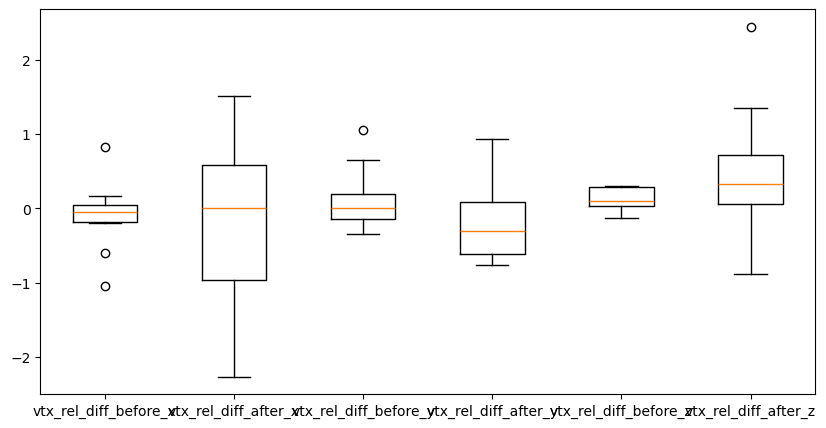

In [116]:
cube_size = model_loader.test_dataset.cube_size
check_fit_result(result, 10, 20, dataset, cube_size)

In [15]:
from utils import plotly_generate
x_recon = result['x_recon_final'].reshape(5,5,5).detach().cpu().numpy()
max_recon = np.max(x_recon)


plotly_generate(x_recon, max_recon)

922
2
6
159
5
1
25
18
4
26
52
921
93
1
10
550
506
9
60
686
23
15
54
3
19
19
3
23
1


In [16]:
x_true = result['x_true'].reshape(5,5,5)
max_true = np.max(x_true)
plotly_generate(x_true, max_true)

1001
3
159
4
49
1000
45
27
535
506
45
686
37
37
39
4
31
40


In [ ]:
print(test_data.keys())

In [ ]:
print(test_data['exit_particle'])

